In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Config
pd.set_option("display.max_columns", None)
sns.set_theme(style="darkgrid")

# Load data
data = pd.read_csv("Linhac24-25_Sportlogiq.csv")

# Overview
print(data.shape)
print(data.dtypes)
print(data.describe())
print(data.isnull().sum())

data.head(150)

(541802, 22)
gameid                             int64
opposingteamgoalieoniceid        float64
opposingteamid                     int64
playerid                           int64
teamgoalieoniceid                float64
teamid                             int64
teaminpossession                 float64
currentpossession                float64
xg_allattempts                   float64
compiledgametime                 float64
eventname                            str
ishomegame                         int64
manpowersituation                    str
opposingteamskatersonicecount      int64
outcome                              str
period                             int64
playerprimaryposition                str
scoredifferential                  int64
teamskatersonicecount              int64
type                                 str
xadjcoord                        float64
yadjcoord                        float64
dtype: object
              gameid  opposingteamgoalieoniceid  opposingteamid  \
coun

,gameid,opposingteamgoalieoniceid,opposingteamid,playerid,teamgoalieoniceid,teamid,teaminpossession,currentpossession,xg_allattempts,compiledgametime,eventname,ishomegame,manpowersituation,opposingteamskatersonicecount,outcome,period,playerprimaryposition,scoredifferential,teamskatersonicecount,type,xadjcoord,yadjcoord
0,72393,553243.0,885,489917,172367.0,814,NaN,NaN,NaN,0.000000,faceoff,1,evenStrength,5,failed,1,F,0,5,none,0.304306,0.251442
1,72393,172367.0,814,435025,553243.0,885,NaN,NaN,NaN,0.000000,faceoff,0,evenStrength,5,successful,1,F,0,5,recovered,-0.304306,-0.251442
2,72393,172367.0,814,435025,553243.0,885,885.0,0.0,NaN,1.333333,lpr,0,evenStrength,5,successful,1,F,0,5,faceoffcontested,0.205826,0.245975
3,72393,553243.0,885,489917,172367.0,814,885.0,0.0,NaN,1.333333,lpr,1,evenStrength,5,failed,1,F,0,5,contested,-0.205826,-0.245975
4,72393,172367.0,814,435025,553243.0,885,885.0,0.0,NaN,2.166667,pass,0,evenStrength,5,successful,1,F,0,5,south,3.223473,3.766563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,72393,172367.0,814,39309,553243.0,885,NaN,NaN,NaN,125.433334,controlledexit,0,powerPlay,4,successful,1,F,-1,5,carrywithplay,-25.947121,-13.780495
146,72393,172367.0,814,39309,553243.0,885,885.0,25.0,NaN,125.433334,carry,0,powerPlay,4,successful,1,F,-1,5,none,-25.947121,-13.780495
147,72393,172367.0,814,39309,553243.0,885,885.0,25.0,NaN,126.333336,pass,0,powerPlay,4,successful,1,F,-1,5,eastwest,-2.811821,-3.721672
148,72393,172367.0,814,307447,553243.0,885,885.0,25.0,NaN,127.066666,reception,0,powerPlay,4,successful,1,F,-1,5,regular,20.323471,36.513622


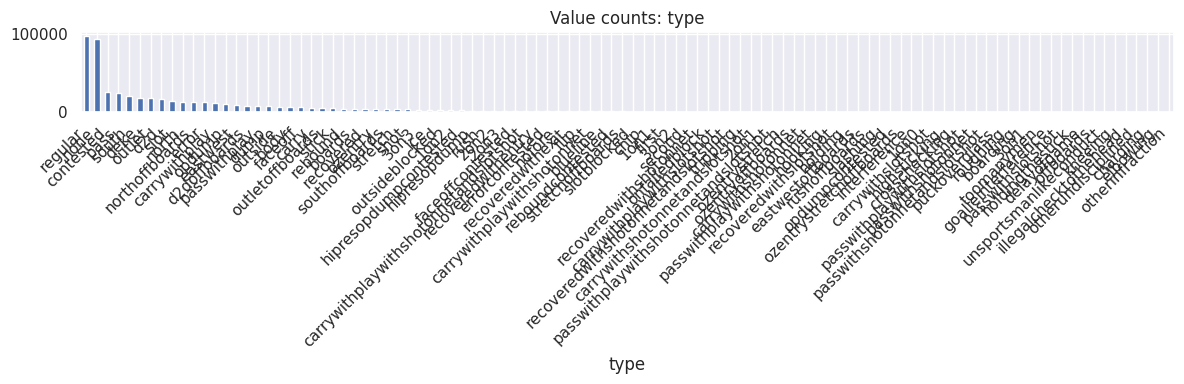

In [6]:
# Distributions of column type 
col = "type"

data[col].value_counts().plot(kind="bar", figsize=(12, 4))
plt.title(f"Value counts: {col}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Identifierad mållinje vid x = 89.8285369873047

Identifierade tekningspunkter:
X: -70.0, Y: -23.0
X: -70.0, Y: -22.0
X: -70.0, Y: -21.0
X: -70.0, Y: 21.0
X: -70.0, Y: 22.0
X: -70.0, Y: 23.0
X: -69.0, Y: -23.0
X: -69.0, Y: -22.0
X: -69.0, Y: -21.0
X: -69.0, Y: 21.0
X: -69.0, Y: 22.0
X: -69.0, Y: 23.0
X: -68.0, Y: -22.0
X: -68.0, Y: -21.0
X: -68.0, Y: 21.0
X: -68.0, Y: 22.0
X: -68.0, Y: 23.0
X: -21.0, Y: -22.0
X: -21.0, Y: 22.0
X: -20.0, Y: -23.0
X: -20.0, Y: -22.0
X: -20.0, Y: -21.0
X: -20.0, Y: 21.0
X: -20.0, Y: 22.0
X: -20.0, Y: 23.0
X: -19.0, Y: -22.0
X: -19.0, Y: -21.0
X: -19.0, Y: 21.0
X: -19.0, Y: 22.0
X: -1.0, Y: -1.0
X: -1.0, Y: 0.0
X: -1.0, Y: 1.0
X: 0.0, Y: -1.0
X: 0.0, Y: 0.0
X: 0.0, Y: 1.0
X: 1.0, Y: -1.0
X: 1.0, Y: 0.0
X: 1.0, Y: 1.0
X: 19.0, Y: -22.0
X: 19.0, Y: -21.0
X: 19.0, Y: 21.0
X: 19.0, Y: 22.0
X: 20.0, Y: -23.0
X: 20.0, Y: -22.0
X: 20.0, Y: -21.0
X: 20.0, Y: 21.0
X: 20.0, Y: 22.0
X: 20.0, Y: 23.0
X: 21.0, Y: -22.0
X: 21.0, Y: 22.0
X: 68.0, Y: -23.0
X: 68.0, Y: -22.

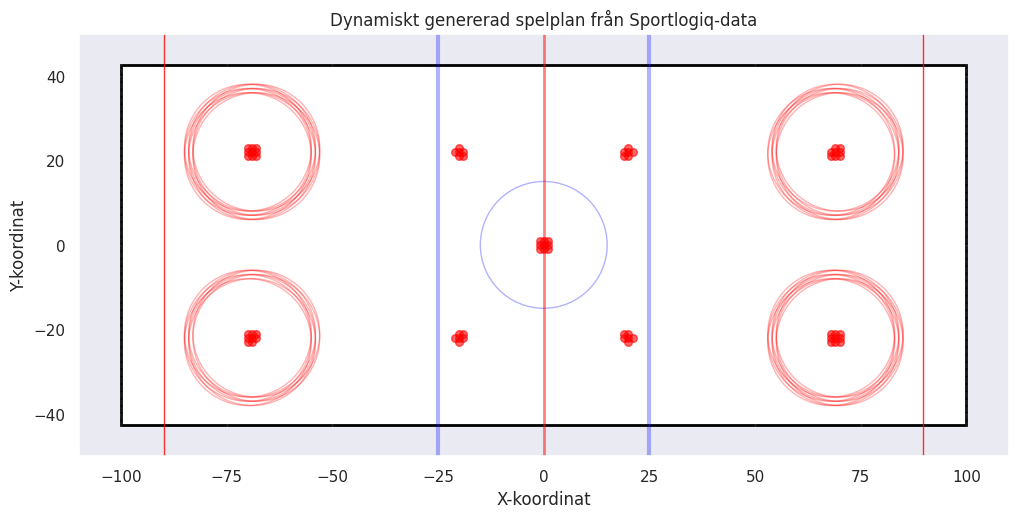

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_ice_with_coords(data):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # 1. Grundinställningar
    rink = patches.Rectangle((-100, -42.5), 200, 85, linewidth=2, edgecolor='black', facecolor='white', zorder=0)
    ax.add_patch(rink)

    # 2. Dynamisk dataextraktion
    # Mållinje (baserat på mål)
    goal_line_x = data[data['eventname'] == 'goal']['xadjcoord'].max()
    
    # Tekningspunkter (Vi grupperar unika koordinat-par för att hitta de 9 punkterna)
    # Vi rundar av för att gruppera små variationer i datan
    faceoffs = data[data['eventname'] == 'faceoff'].copy()
    faceoffs['x_round'] = faceoffs['xadjcoord'].round(0)
    faceoffs['y_round'] = faceoffs['yadjcoord'].round(0)
    
    # Hitta de vanligaste unika punkterna (normalt 9 st på en rink)
    coords = faceoffs.groupby(['x_round', 'y_round']).size().reset_index()
    # Filtrera bort "skräp" genom att bara ta punkter med många händelser
    coords = coords[coords[0] > 10] 
    
    print(f"Identifierad mållinje vid x = {goal_line_x}")
    print("\nIdentifierade tekningspunkter:")
    for _, row in coords.iterrows():
        print(f"X: {row['x_round']}, Y: {row['y_round']}")

    # 3. Rita linjer
    plt.axvline(0, color='red', linewidth=2, alpha=0.5) # Mittlinje
    plt.axvline(25, color='blue', linewidth=3, alpha=0.3) # Blålinjer
    plt.axvline(-25, color='blue', linewidth=3, alpha=0.3)
    plt.axvline(goal_line_x, color='red', linewidth=1, alpha=0.8) # Mållinjer
    plt.axvline(-goal_line_x, color='red', linewidth=1, alpha=0.8)

    # 4. Rita tekningscirklar och punkter dynamiskt
    for _, row in coords.iterrows():
        x, y = row['x_round'], row['y_round']
        # Rita punkten
        ax.scatter(x, y, color='red', s=30, alpha=0.6, zorder=3)
        
        # Rita cirkel runt punkten (skippa de vid blålinjerna om man vill vara petig, 
        # men standard är cirklar i anfallszon och mittcirkel)
        if abs(x) > 50 or (x == 0 and y == 0):
            color = 'blue' if x == 0 else 'red'
            circle = plt.Circle((x, y), 15, color=color, fill=False, linewidth=1, alpha=0.3)
            ax.add_patch(circle)

    # 5. Formatering
    ax.set_xlabel('X-koordinat')
    ax.set_ylabel('Y-koordinat')
    ax.set_aspect('equal')
    plt.xlim(-110, 110)
    plt.ylim(-50, 50)
    ax.grid(True, linestyle='--', alpha=0.1)
    
    return ax

# Kör funktionen (skicka med din 'data' variabel)
ax = draw_ice_with_coords(data)
plt.title("Dynamiskt genererad spelplan från Sportlogiq-data")
plt.show()

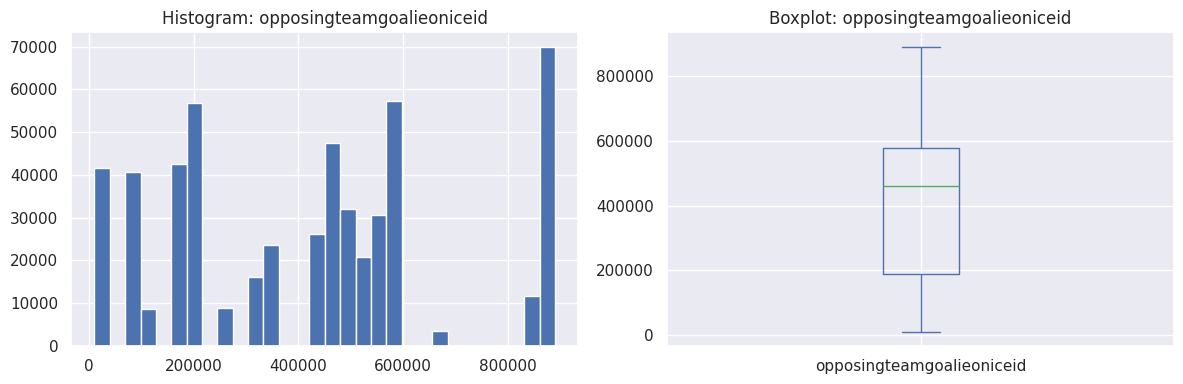

In [8]:
# Distributions of column opposingteamgoalieoniceid 
col = "opposingteamgoalieoniceid"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data[col].hist(bins=30, ax=axes[0])
axes[0].set_title(f"Histogram: {col}")
data[col].plot(kind="box", ax=axes[1])
axes[1].set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

In [ ]:
pass_pos = data[(data['eventname'] == 'pass')]
pass_pox_x, pass_pos_y = pass_pos['xadjcoord'], pass_pos['yadjcoord']
#print(pass_pox_x, pass_pos_y)

events = []
for event in data['eventname']:
    if event not in events:
        events.append(event)
        
types = []
for type in data['type']:
    if type not in types:
        types.append(type)
        
outcomes = []
for outcome in data['outcome']:
    if outcome not in outcomes:
        outcomes.append(outcome)
print(events)
print(types)
print(outcomes)

data[data['eventname'] == 'reception']['type'].value_counts()

# Skapa en dataframe med bara tekningar
faceoffs = data[data['eventname'] == 'faceoff']

# Printa x- och y-koordinaterna för alla tekningar
print(faceoffs[['xadjcoord', 'yadjcoord']])

#Kopplade till zoningång controlledentryagainst, controlledentry, dumpin

['faceoff', 'lpr', 'pass', 'reception', 'block', 'puckprotection', 'carry', 'check', 'controlledentryagainst', 'controlledentry', 'controlledexit', 'icing', 'dumpout', 'dumpin', 'shot', 'penalty', 'penaltydrawn', 'save', 'rebound', 'assist', 'goal', 'offside', 'soshot', 'sogoal', 'sopuckprotection']
['none', 'recovered', 'faceoffcontested', 'contested', 'south', 'regular', 'north', 'pass', 'body', 'deke', 'stick', '3on2', 'carry', 'ozentry', 'northoffboards', 'd2doffboards', 'errorcontested', 'error', 'outletoffboards', 'recoveredwithexit', 'faceoff', 'd2d', 'boards', 'blueline', 'opdump', 'dump', 'outlet', '1on1', 'outside', 'boarding', 'recoveredwithshotonnet', 'rebound', 'slot', 'carrywithplay', '2on2', 'carrywithplaywithshotonnetandslotshot', 'first', 'carrywithplaywithslotshot', '3on3', 'eastwest', 'ice', 'passwithplay', 'passwithplaywithshotonnetandslotshot', 'hipresopdump', 'rush', 'stretch', 'hipresopdumpcontested', 'outsideblocked', 'recoveredwithentry', 'slotblocked', 'shot',

type
regular    97372
ozentry     2024
Name: count, dtype: int64

**Sort the data in a chronoligical order**

In [10]:
sorted_data = data.sort_values(by=['gameid', 'compiledgametime']) 
print(sorted_data)

sorted_data['prev_event'] = sorted_data.groupby('gameid')['eventname'].shift(1) #groupby sepereates the data for different games
sorted_data['next_event'] = sorted_data.groupby('gameid')['eventname'].shift(-1)

print(sorted_data[['gameid', 'compiledgametime', 'prev_event', 'eventname', 'next_event']].head(10))


        gameid  opposingteamgoalieoniceid  opposingteamid  playerid  \
216496   60062                   170439.0             855    463268   
216497   60062                   199899.0             634    412148   
216498   60062                   170439.0             855    463268   
216499   60062                   199899.0             634    412148   
216500   60062                   199899.0             634    412148   
...        ...                        ...             ...       ...   
531165   89893                   316087.0             792    133246   
531166   89893                   316087.0             792    133246   
531167   89893                   199899.0             634    823725   
531168   89893                   316087.0             792    133246   
531169   89893                   316087.0             792    133246   

        teamgoalieoniceid  teamid  teaminpossession  currentpossession  \
216496           199899.0     634               NaN                NaN   

In [11]:

pp_goals = sorted_data[
    (sorted_data['eventname'] == 'goal') & 
    (sorted_data['manpowersituation'] == 'powerPlay')
].copy()

# Ge varje mål ett unikt ID så vi kan skilja på olika målsekvenser
pp_goals['goal_id'] = range(len(pp_goals))

goal_lookup = pp_goals[['gameid', 'compiledgametime', 'goal_id', 'teamid']].rename(
    columns={'compiledgametime': 'goal_time', 'teamid': 'scoring_teamid'}
)
#Dataframe for only shots

sequences = pd.merge(sorted_data, goal_lookup, on='gameid')

# 4. Filtrera fram händelser som skedde t.ex. 20 sekunder INNAN målet
# Vi vill också ofta (men inte alltid) bara se händelser från det lag som gjorde mål
time_window = 20
pp_sequences = sequences[
    (sequences['compiledgametime'] <= sequences['goal_time']) & 
    (sequences['compiledgametime'] >= sequences['goal_time'] - time_window) &
    (sequences['teamid'] == sequences['scoring_teamid']) # Valfritt: bara det anfallande laget
].copy()

# 5. Resultat: Nu kan du se sekvensen för varje mål
# Vi sorterar så att det blir lättläst
pp_sequences = pp_sequences.sort_values(by=['goal_id', 'compiledgametime'])

# Exempel: Visa sekvensen för det första PP-målet
print(pp_sequences[pp_sequences['goal_id'] == 0][['compiledgametime', 'eventname', 'type', 'xadjcoord', 'yadjcoord']])





      compiledgametime        eventname                           type  \
2340           1177.08             pass                       eastwest   
2342           1178.12        reception                        regular   
2344           1178.60             pass                       eastwest   
2346           1179.76        reception                        regular   
2348           1180.52           dumpin                           dump   
2356           1185.72              lpr                         opdump   
2358           1186.96             pass                       eastwest   
2360           1187.72        reception                        regular   
2362           1188.44             pass                       eastwest   
2364           1189.56        reception                        regular   
2366           1190.24            carry                           none   
2368           1190.24  controlledentry  carrywithshotonnetandslotshot   
2372           1190.88             pas

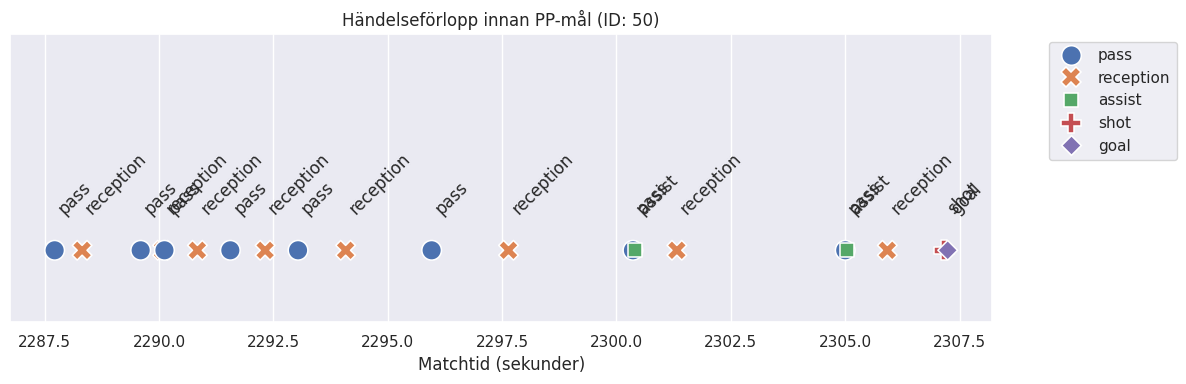

In [12]:

# Välj ett specifikt mål att visualisera (t.ex. mål_id 0)
goal_id_to_plot = 50
single_seq = pp_sequences[pp_sequences['goal_id'] == goal_id_to_plot]

plt.figure(figsize=(12, 4))
sns.scatterplot(data=single_seq, x='compiledgametime', y=[1]*len(single_seq), 
                hue='eventname', s=200, style='eventname')

# Lägg till textetiketter för varje händelse
for i, row in single_seq.iterrows():
    plt.text(row['compiledgametime'], 1.05, row['eventname'], 
             rotation=45, horizontalalignment='left')

plt.title(f'Händelseförlopp innan PP-mål (ID: {goal_id_to_plot})')
plt.xlabel('Matchtid (sekunder)')
plt.yticks([]) # Ta bort y-axeln då den inte behövs
plt.ylim(0.9, 1.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

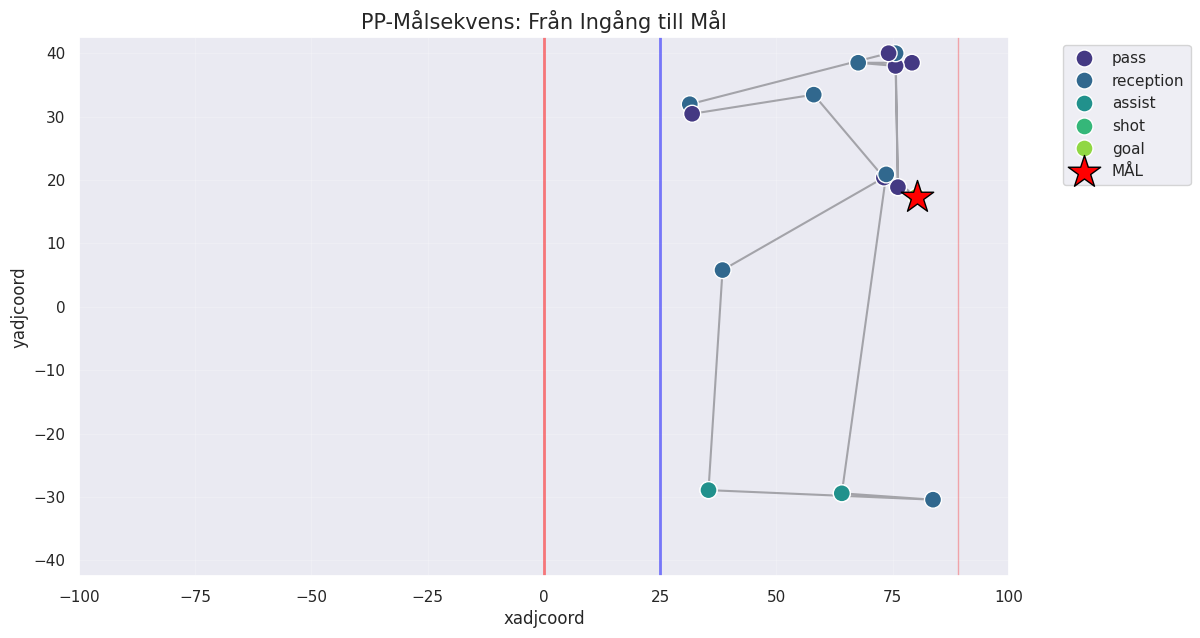

In [13]:


plt.figure(figsize=(12, 7))

# Rita rinken (Anfallszonen är till höger, x > 25)
# Blålinjen är vid x = 25, Mittlinjen vid x = 0, Mållinjen vid x = 89
plt.axvline(0, color='red', linewidth=2, alpha=0.5)  # Mittlinje
plt.axvline(25, color='blue', linewidth=2, alpha=0.5) # Blålinje
plt.axvline(89, color='red', linewidth=1, alpha=0.3)  # Mållinje

# Plotta puckvägen
plt.plot(single_seq['xadjcoord'], single_seq['yadjcoord'], 
         color='black', linestyle='-', alpha=0.3, zorder=1)

# Plotta händelser
sns.scatterplot(data=single_seq, x='xadjcoord', y='yadjcoord', 
                hue='eventname', s=150, zorder=3, palette='viridis')

# Markera målet extra tydligt
goal_row = single_seq[single_seq['eventname'] == 'goal']
if not goal_row.empty:
    plt.scatter(goal_row['xadjcoord'], goal_row['yadjcoord'], 
                color='red', marker='*', s=600, label='MÅL', zorder=5, edgecolors='black')

# Sätt gränserna för anfallszonen (+ lite av mittzon)
plt.xlim(-100, 100) 
plt.ylim(-42.5, 42.5)

plt.title('PP-Målsekvens: Från Ingång till Mål' , fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

### Clustra ihop olika sekvenser

Genomsnittliga egenskaper per kluster:
         x_mean  x_std  x_min  y_mean  y_std  num_passes  num_carries  \
cluster                                                                 
0         59.49  20.94  25.64    1.45  23.26        5.79         0.11   
1         23.66  50.02 -73.59   -0.67  22.03        5.07         1.82   
2         59.37  19.63  27.00   -2.54  21.02        8.64         0.16   

         total_events  duration  
cluster                          
0               19.24     18.87  
1               21.01     17.95  
2               25.00     18.97  


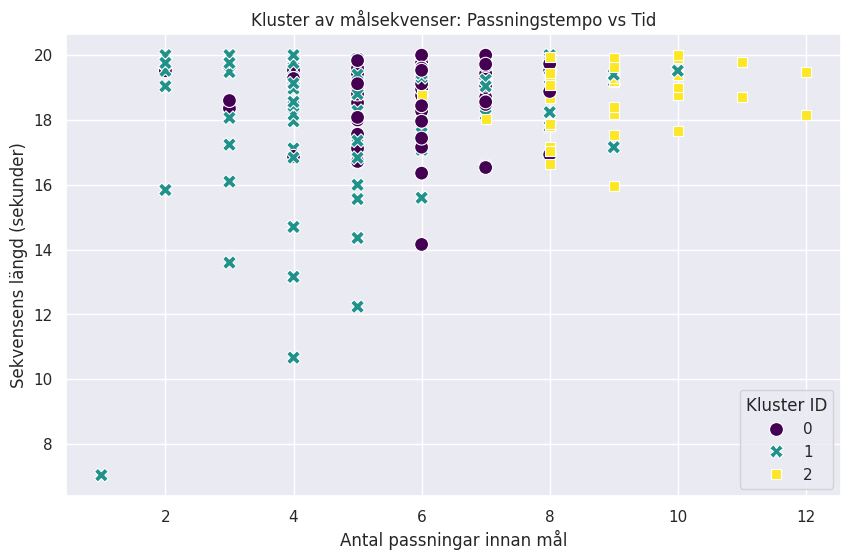

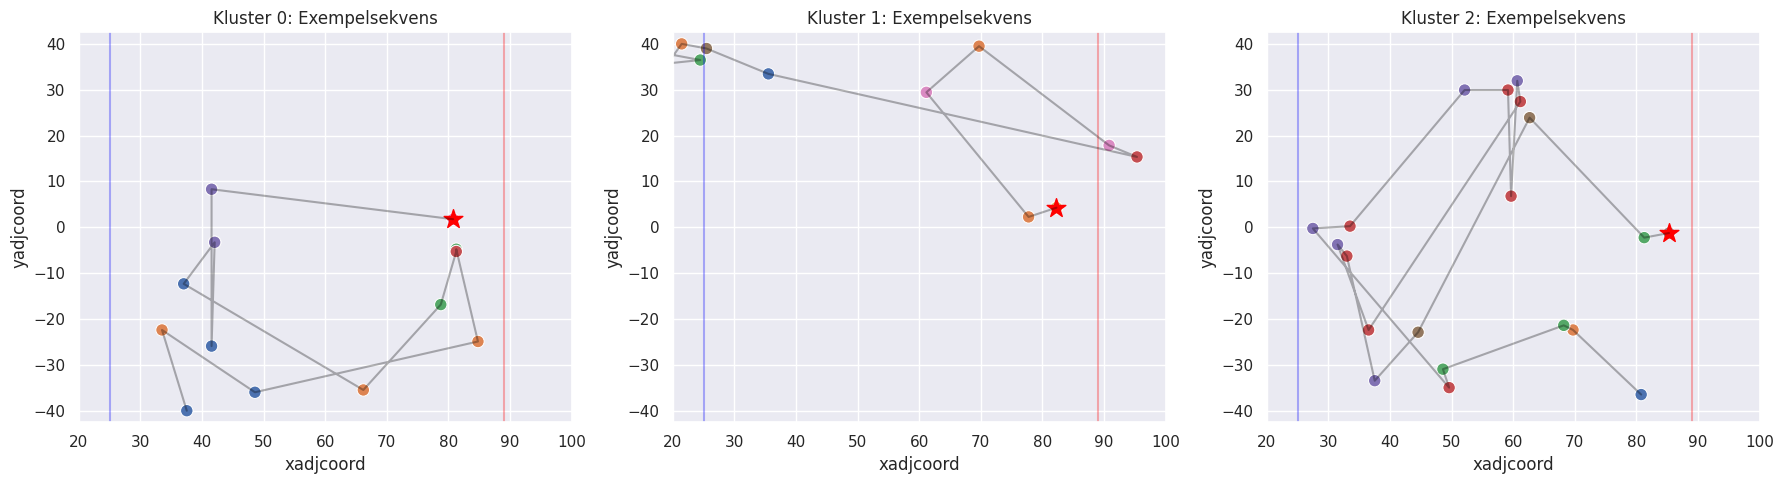

In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def create_cluster_features(df_sequences):
    # Vi grupperar på goal_id för att sammanfatta vad som hände innan målet
    features = df_sequences.groupby('goal_id').agg({
        'xadjcoord': ['mean', 'std', 'min'], # Position i djupled
        'yadjcoord': ['mean', 'std'],        # Position i sidled (spridning)
        'eventname': [
            lambda x: (x == 'pass').sum(),   # Antal passningar i sekvensen
            lambda x: (x == 'carry').sum(),  # Antal pucktransporter
            'count'                          # Totala antalet händelser
        ],
        'compiledgametime': lambda x: x.max() - x.min() # Sekvensens varaktighet i sekunder
    })

    # Platta till kolumnnamnen för enklare hantering
    features.columns = [
        'x_mean', 'x_std', 'x_min', 
        'y_mean', 'y_std', 
        'num_passes', 'num_carries', 'total_events', 
        'duration'
    ]
    
    # Hantera eventuella NaN (t.ex. om std inte kan beräknas på en händelse)
    return features.fillna(0)

# Skapa feature-matrisen
features_df = create_cluster_features(pp_sequences)

# ==========================================
# 2. PREPROCESSING OCH KLUSTERING
# ==========================================

# Skala datan (Viktigt! K-Means baseras på avstånd, så alla enheter måste vara jämförbara)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

# Vi väljer 3 kluster som utgångspunkt (t.ex. "Direktavslut", "Långt tryck", "Kontring/Ingång")
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
features_df['cluster'] = kmeans.fit_predict(scaled_features)

# Koppla tillbaka kluster-ID till den ursprungliga sekvens-datan
pp_sequences = pp_sequences.merge(features_df[['cluster']], on='goal_id', how='left')

# ==========================================
# 3. ANALYS OCH VISUALISERING AV KLUSTER
# ==========================================

# Kolla genomsnittet för varje kluster för att tolka dem
cluster_interpretation = features_df.groupby('cluster').mean()
print("Genomsnittliga egenskaper per kluster:")
print(cluster_interpretation.round(2))

# Visualisera klustren i en Scatterplot (t.ex. Antal passningar vs Varaktighet)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=features_df, 
    x='num_passes', 
    y='duration', 
    hue='cluster', 
    palette='viridis', 
    s=100, 
    style='cluster'
)
plt.title('Kluster av målsekvenser: Passningstempo vs Tid')
plt.xlabel('Antal passningar innan mål')
plt.ylabel('Sekvensens längd (sekunder)')
plt.legend(title='Kluster ID')
plt.show()

# ==========================================
# 4. EXEMPEL: PLOTTA TYPISKA MÅL FRÅN VARJE KLUSTER
# ==========================================

fig, axes = plt.subplots(1, num_clusters, figsize=(18, 5))

for i in range(num_clusters):
    # Hitta första målet i detta kluster för att visa som exempel
    example_goal_id = features_df[features_df['cluster'] == i].index[0]
    example_seq = pp_sequences[pp_sequences['goal_id'] == example_goal_id]
    
    ax = axes[i]
    # Rita rink-linjer (symboliskt)
    ax.axvline(25, color='blue', alpha=0.3) # Blålinje
    ax.axvline(89, color='red', alpha=0.3)  # Mållinje
    
    # Plotta puckvägen
    ax.plot(example_seq['xadjcoord'], example_seq['yadjcoord'], color='black', alpha=0.3)
    sns.scatterplot(data=example_seq, x='xadjcoord', y='yadjcoord', hue='eventname', ax=ax, s=80, legend=False)
    
    # Markera målet
    goal_row = example_seq[example_seq['eventname'] == 'goal']
    ax.scatter(goal_row['xadjcoord'], goal_row['yadjcoord'], color='red', marker='*', s=200)
    
    ax.set_title(f'Kluster {i}: Exempelsekvens')
    ax.set_xlim(20, 100) # Fokus på anfallszon
    ax.set_ylim(-42.5, 42.5)

plt.tight_layout()
plt.show()

         num_passes  duration  x_mean  y_std
cluster                                     
0              5.79     18.87   59.49  23.26
1              5.07     17.95   23.66  22.03
2              8.64     18.97   59.37  21.02


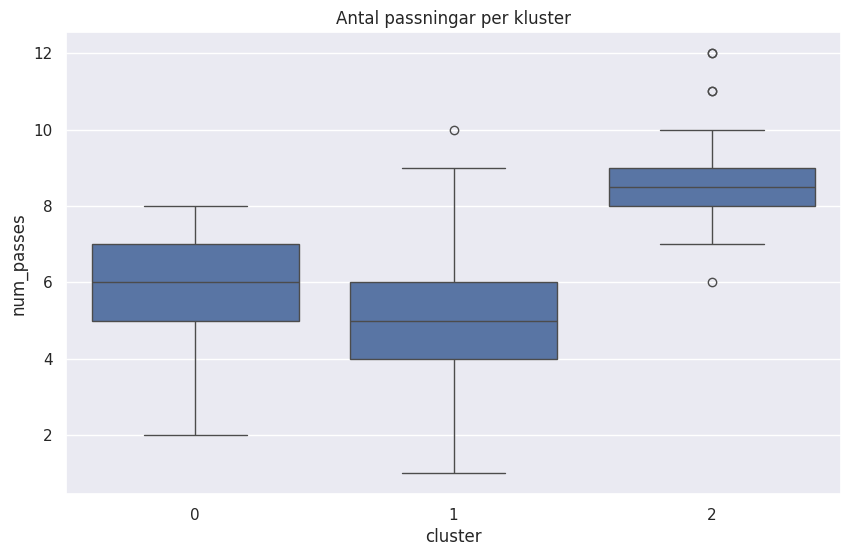

In [15]:
# Beräkna medelvärdet för varje egenskap per kluster
interpretation = features_df.groupby('cluster').mean()

# Snygga till presentationen
print(interpretation[['num_passes', 'duration', 'x_mean', 'y_std']].round(2))
# Skapa en boxplot för att se skillnaden i antal passningar mellan klustren
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='num_passes', data=features_df)
plt.title('Antal passningar per kluster')
plt.show()


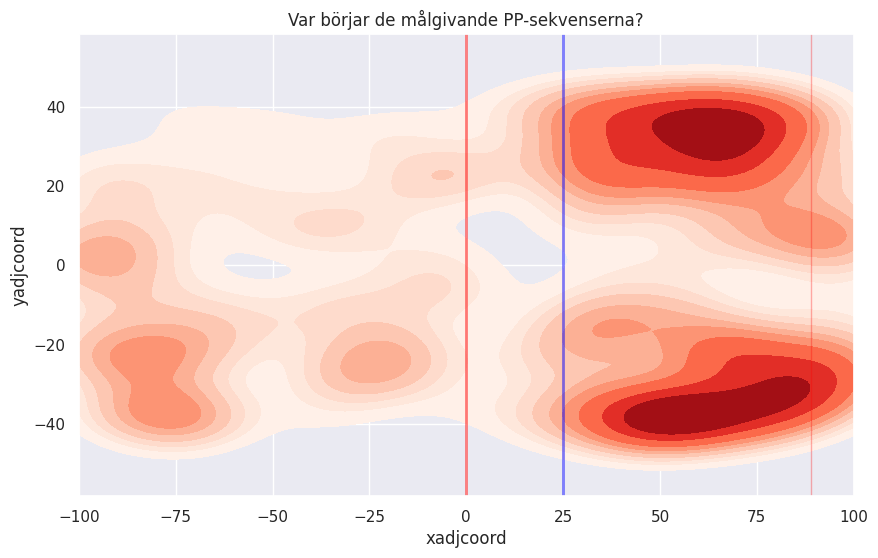

In [16]:
# Hämta den första händelsen i varje målsekvens
starts = pp_sequences.groupby('goal_id').first()

plt.figure(figsize=(10, 6))
plt.axvline(0, color='red', linewidth=2, alpha=0.5)  # Mittlinje
plt.axvline(25, color='blue', linewidth=2, alpha=0.5) # Blålinje
plt.axvline(89, color='red', linewidth=1, alpha=0.3)  # Mållinje
sns.kdeplot(data=starts, x='xadjcoord', y='yadjcoord', cmap="Reds", fill=True, bw_adjust=.5)
plt.title('Var börjar de målgivande PP-sekvenserna?')
plt.xlim(-100, 100) # Fokus på anfallszon
plt.show()

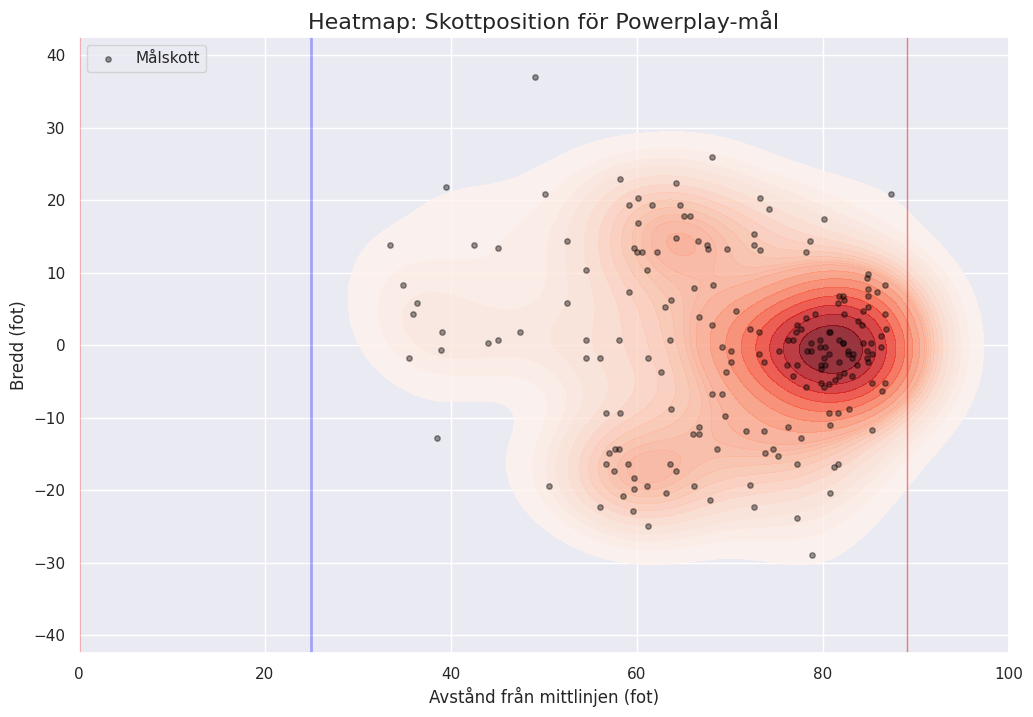

In [17]:


# 2. Skapa plotten
plt.figure(figsize=(12, 8))

# KDE-plot skapar själva "värmen" (densiteten)
sns.kdeplot(
    data=pp_goals, 
    x='xadjcoord', 
    y='yadjcoord', 
    fill=True, 
    cmap='Reds', 
    thresh=0.05, 
    levels=20, 
    alpha=0.8
)

# Lägg till de faktiska punkterna för att se exakt spridning
plt.scatter(pp_goals['xadjcoord'], pp_goals['yadjcoord'], color='black', s=15, alpha=0.4, label='Målskott')

# 3. Rita ut rinkens linjer (förutsatt att anfallszonen är till höger, x > 25)
plt.axvline(0, color='red', linewidth=2, alpha=0.3)   # Mittlinje
plt.axvline(25, color='blue', linewidth=2, alpha=0.3) # Blålinje
plt.axvline(89, color='red', linewidth=1, alpha=0.5)  # Mållinje (ca 11 fot från kortsarg)

# Begränsa vyn till anfallshalvan
plt.xlim(0, 100) 
plt.ylim(-42.5, 42.5)

plt.title('Heatmap: Skottposition för Powerplay-mål', fontsize=16)
plt.xlabel('Avstånd från mittlinjen (fot)')
plt.ylabel('Bredd (fot)')
plt.legend()
plt.show()

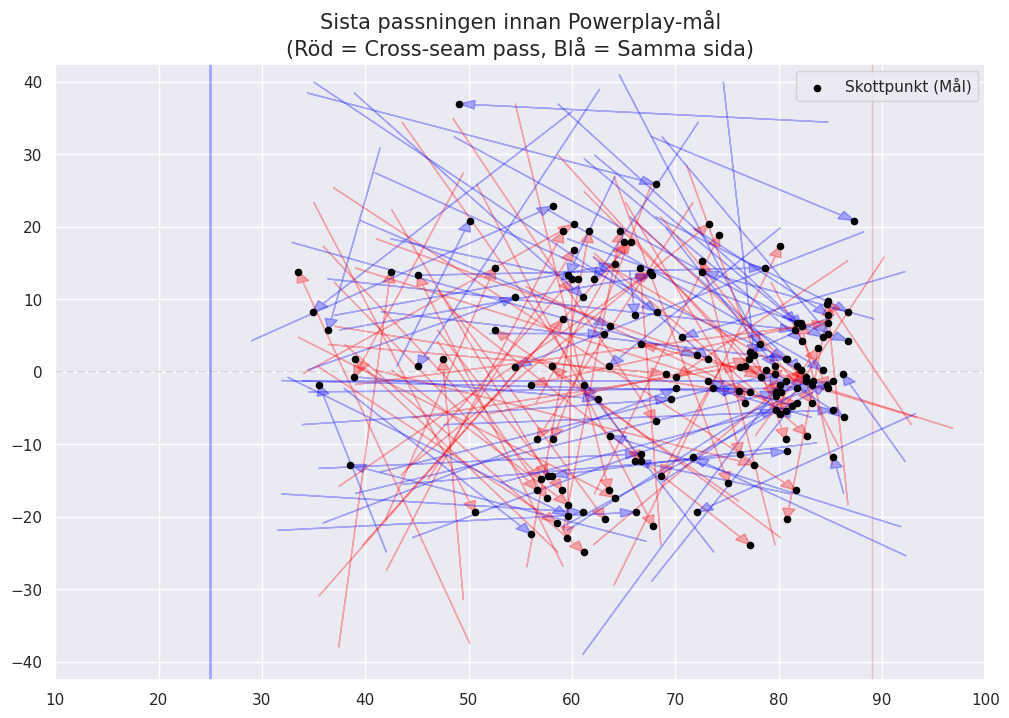

Antal analyserade PP-passningar: 156


In [18]:
pass_data = []

for _, goal in pp_goals.iterrows():
    # Hitta händelser precis innan målet (max 3 sekunder för att vara säker på att det är direkt assist)
    # Vi kollar samma match och samma lag
    prior_events = sorted_data[
        (sorted_data['gameid'] == goal['gameid']) &
        (sorted_data['teamid'] == goal['teamid']) &
        (sorted_data['compiledgametime'] < goal['compiledgametime']) &
        (sorted_data['compiledgametime'] >= goal['compiledgametime'] - 3)
    ].sort_values('compiledgametime', ascending=False)
    
    # Hämta den senaste passningen
    last_pass = prior_events[prior_events['eventname'] == 'pass'].head(1)
    
    if not last_pass.empty:
        pass_data.append({
            'start_x': last_pass.iloc[0]['xadjcoord'],
            'start_y': last_pass.iloc[0]['yadjcoord'],
            'end_x': goal['xadjcoord'],
            'end_y': goal['yadjcoord'],
            'cross_crease': (last_pass.iloc[0]['yadjcoord'] * goal['yadjcoord'] < 0) # Sant om y byter tecken (+ till -)
        })

df_pass = pd.DataFrame(pass_data)

# 2. Visualisering
plt.figure(figsize=(12, 8))

# Rita ut rinken (Anfallszon höger)
plt.axvline(0, color='red', linewidth=2, alpha=0.2)   # Mittlinje
plt.axvline(25, color='blue', linewidth=2, alpha=0.3) # Blålinje
plt.axvline(89, color='red', linewidth=1, alpha=0.2)  # Mållinje
plt.axhline(0, color='black', linestyle='--', alpha=0.1) # Centerlinje (Royal Road-markör)

# Rita passen
for _, row in df_pass.iterrows():
    color = 'red' if row['cross_crease'] else 'blue'
    plt.arrow(row['start_x'], row['start_y'], 
              row['end_x'] - row['start_x'], row['end_y'] - row['start_y'], 
              head_width=1.2, head_length=1.5, fc=color, ec=color, alpha=0.3, length_includes_head=True)

# Markera skottpunkten (målet)
plt.scatter(df_pass['end_x'], df_pass['end_y'], color='black', s=20, label='Skottpunkt (Mål)')

plt.xlim(10, 100)
plt.ylim(-42.5, 42.5)
plt.title('Sista passningen innan Powerplay-mål\n(Röd = Cross-seam pass, Blå = Samma sida)', fontsize=15)
plt.legend()
plt.show()

print(f"Antal analyserade PP-passningar: {len(df_pass)}")

In [19]:
# 1. Sortera och förbered
df = sorted_data.sort_values(['gameid', 'compiledgametime']).copy()

# 2. Hitta starten på varje Powerplay
# Ett PP börjar när manpowersituation ändras till powerPlay
df['is_pp'] = (df['manpowersituation'] == 'powerPlay').astype(int)
df['pp_start'] = (df['is_pp'] == 1) & (df['is_pp'].shift(1) == 0)
df['pp_id'] = df.groupby('gameid')['pp_start'].cumsum()

# 3. Markera PP som delas av en periodpaus
# Vi tittar på varje pp_id och ser om det innehåller mer än ett period-nummer
pp_info = df[df['is_pp'] == 1].groupby(['gameid', 'pp_id']).agg({
    'period': ['min', 'max', 'nunique'],
    'eventname': lambda x: (x == 'goal').any() # Gjordes mål under detta PP?
}).reset_index()

pp_info.columns = ['gameid', 'pp_id', 'period_min', 'period_max', 'period_count', 'made_goal']

# Kategorisera
# 'Interrupted' = PP som spänner över mer än 1 period
# 'Continuous' = PP som spelas klart i samma period
pp_info['category'] = 'Continuous'
pp_info.loc[pp_info['period_count'] > 1, 'category'] = 'Interrupted'

# 4. Räkna ut andelen mål
resultat = pp_info.groupby('category')['made_goal'].mean() * 100

print("Andel Powerplay som resulterar i mål:")
print(resultat)

# Visa antal för att se underlaget
print("\nAntal Powerplay i varje kategori:")
print(pp_info['category'].value_counts())
print(df['manpowersituation'].value_counts())


Andel Powerplay som resulterar i mål:
category
Continuous     1.853486
Interrupted    0.000000
Name: made_goal, dtype: float64

Antal Powerplay i varje kategori:
category
Continuous     10197
Interrupted       11
Name: count, dtype: int64
manpowersituation
evenStrength    463668
powerPlay        59271
shortHanded      18863
Name: count, dtype: int64


### Plots where teams shot from in Powerplay

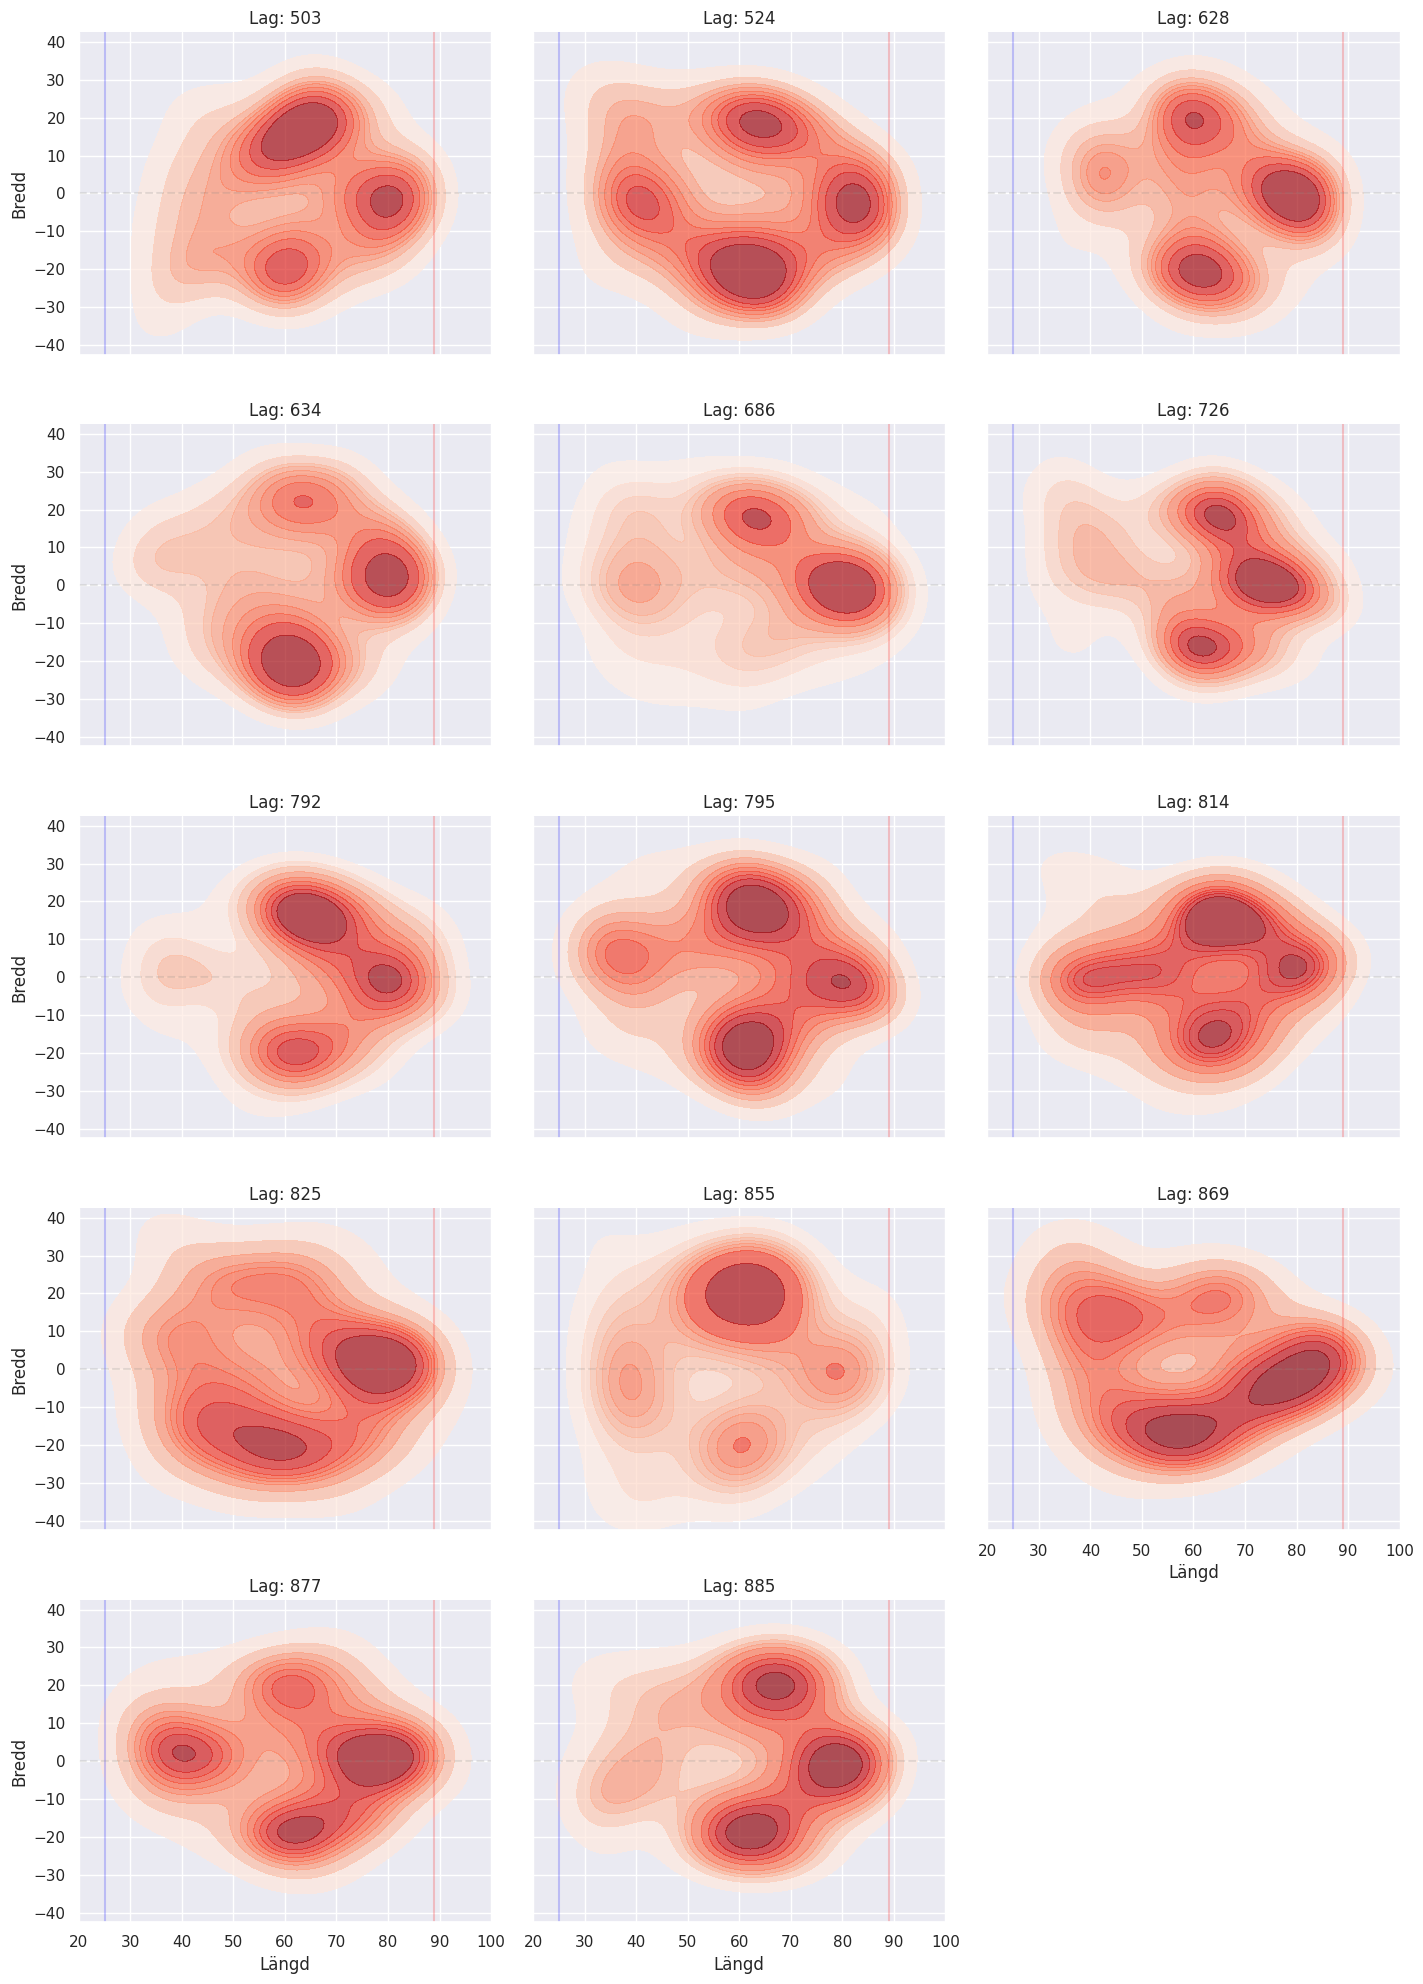

side    Höger  Vänster  Vänster_Procent
teamid                                 
855        65       91        58.333333
686       116      148        56.060606
726       114      135        54.216867
877        79       92        53.801170
634        67       76        53.146853
795        83       91        52.298851
814        90       97        51.871658
825        61       64        51.200000
869        97      101        51.010101
628        79       81        50.625000
885       102      104        50.485437
503       116      115        49.783550
792        72       71        49.650350
524       116       95        45.023697


In [20]:
# Filtrera fram alla skottförsök i Powerplay
# Vi inkluderar både mål och missade skott för att få ett större underlag
pp_shots = df[
    (df['manpowersituation'] == 'powerPlay') & 
    ((df['eventname'] == 'shot') | (df['eventname'] == 'goal'))
].copy()

# För att lättare se vänster/höger kan vi skapa en kolumn som mappar teamid till lagnamn 
# (Om du har en sådan lista, annars använder vi teamid)

# Vi väljer ut de lag som har flest skott för att få tydliga mönster
top_teams = pp_shots['teamid'].value_counts().index
filter_df = pp_shots[pp_shots['teamid'].isin(top_teams)]

# Skapa en grid av plots
g = sns.FacetGrid(filter_df, col="teamid", col_wrap=3, height=4, aspect=1.2)

# Rita rinken (symboliskt) på varje sub-plot
def draw_rink_mini(*args, **kwargs):
    plt.axvline(25, color='blue', alpha=0.2) # Blålinje
    plt.axvline(89, color='red', alpha=0.2)  # Mållinje
    plt.axhline(0, color='grey', linestyle='--', alpha=0.2)

g.map(draw_rink_mini)

# Lägg på en heatmap (KDE) för varje lag
g.map_dataframe(sns.kdeplot, x="xadjcoord", y="yadjcoord", 
                fill=True, cmap="Reds", alpha=0.7, thresh=0.1)

# Sätt gränser för anfallszon
g.set(xlim=(20, 100), ylim=(-42.5, 42.5))
g.set_axis_labels("Längd", "Bredd")
g.set_titles("Lag: {col_name}")

plt.tight_layout()
plt.show()


# Definiera sidor (y > 0 är ena sidan, y < 0 är andra)
pp_shots['side'] = pp_shots['yadjcoord'].apply(lambda y: 'Vänster' if y > 0 else 'Höger')

side_distribution = pp_shots.groupby(['teamid', 'side']).size().unstack(fill_value=0)
side_distribution['Vänster_Procent'] = (side_distribution['Vänster'] / (side_distribution['Vänster'] + side_distribution['Höger'])) * 100

print(side_distribution.sort_values(by='Vänster_Procent', ascending=False))

### Plots where teams score goals in Powerplay

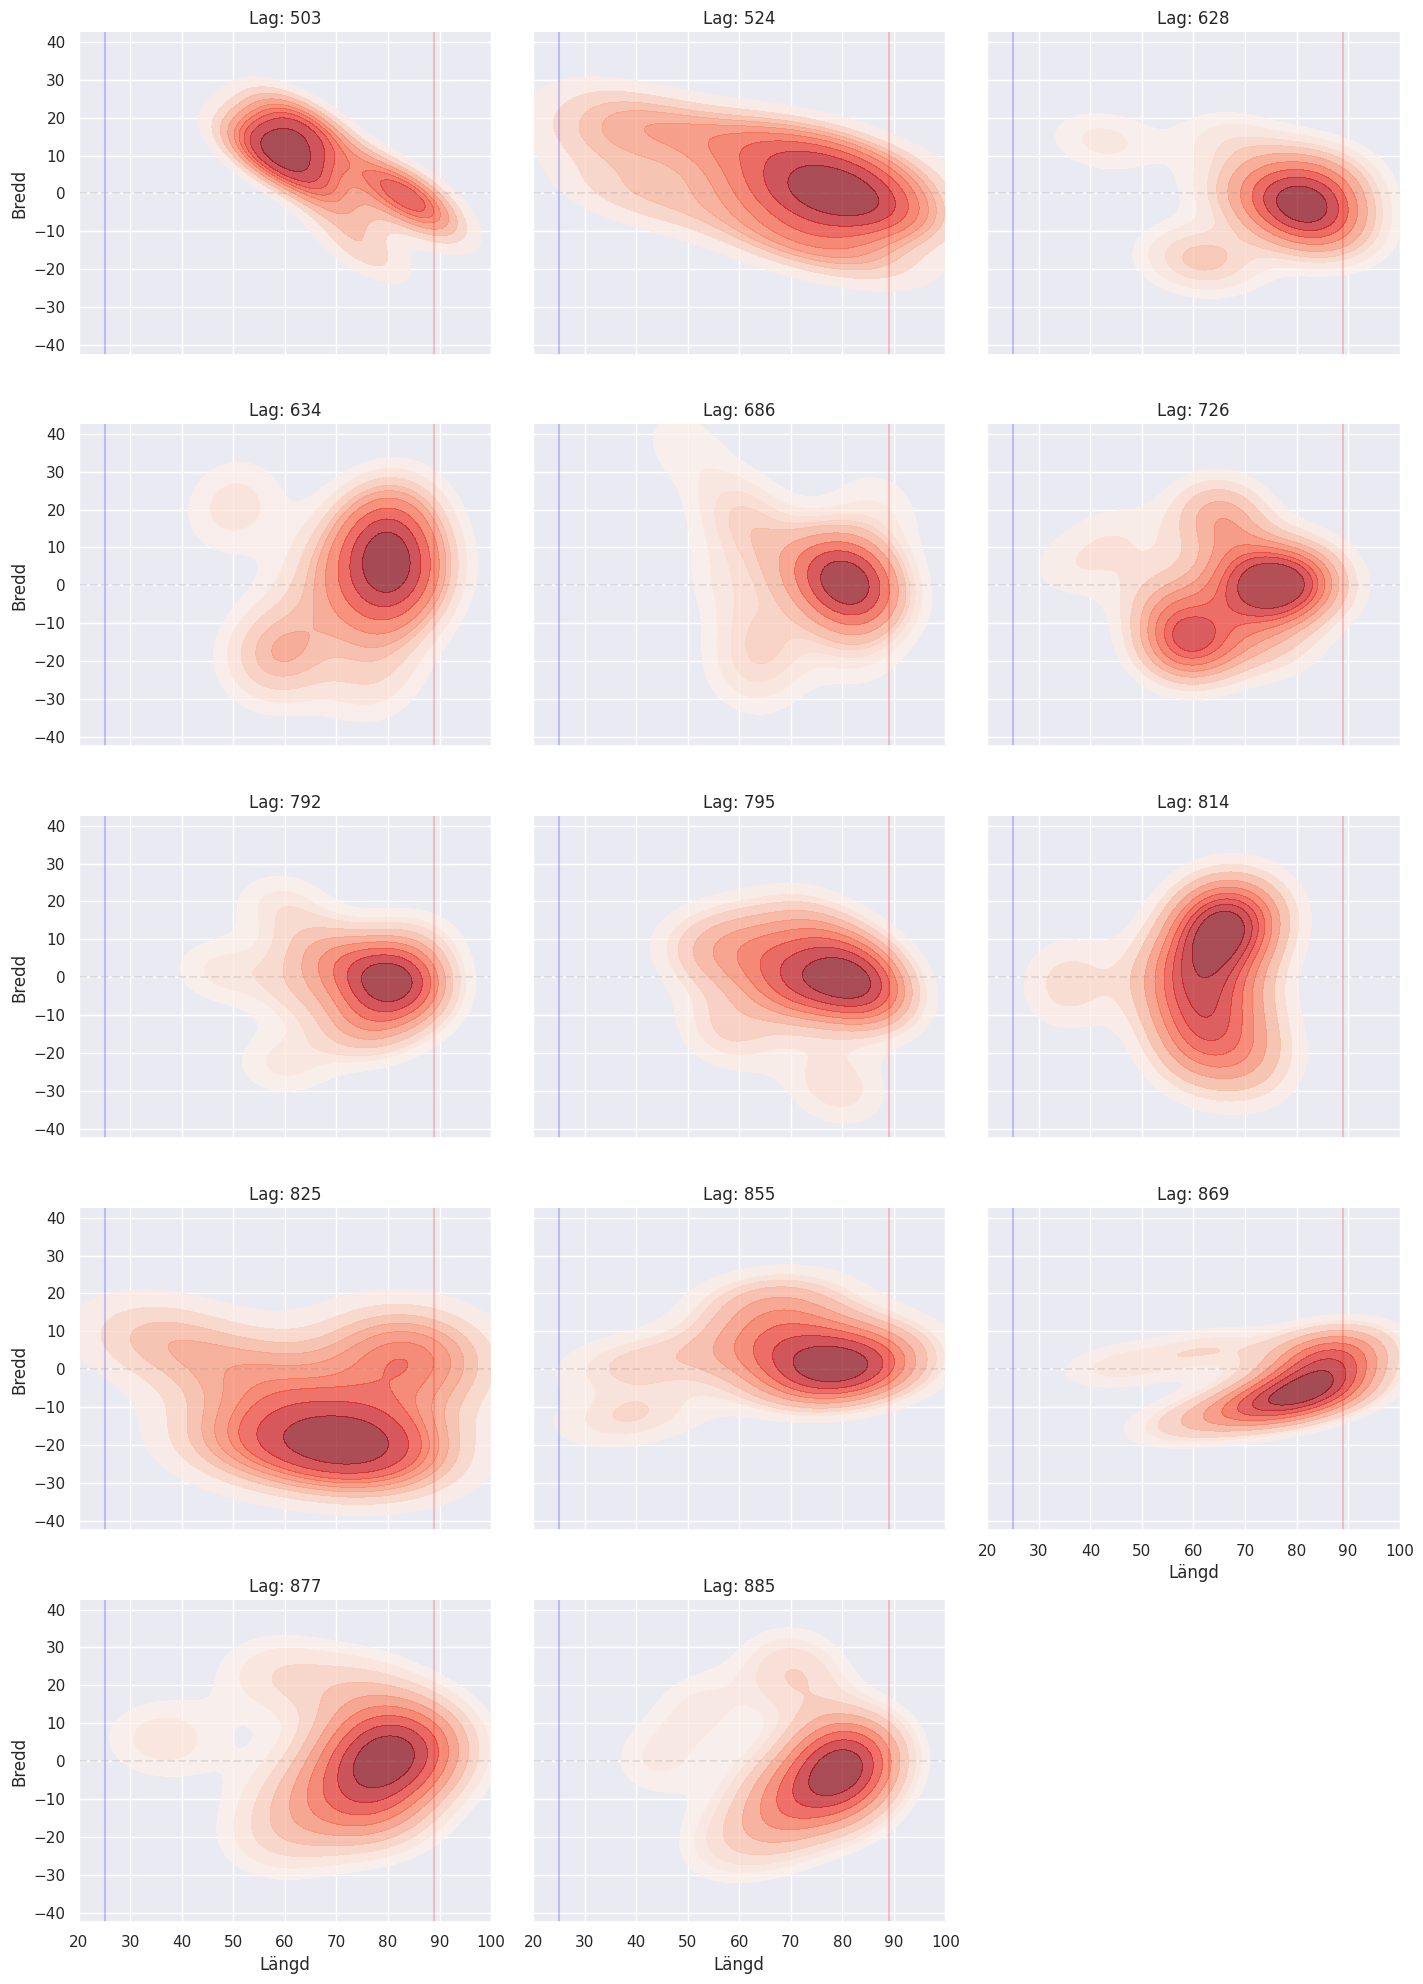

side    Höger  Vänster  Vänster_Procent
teamid                                 
503         3        8        72.727273
855         3        7        70.000000
686         7       14        66.666667
634         5        7        58.333333
877         6        7        53.846154
524         6        6        50.000000
814         6        5        45.454545
726        12        9        42.857143
885        10        7        41.176471
792         9        6        40.000000
869         8        5        38.461538
795         7        4        36.363636
628         9        5        35.714286
825         6        2        25.000000


In [21]:
# Filtrera fram alla skottförsök i Powerplay
# Vi inkluderar både mål och missade skott för att få ett större underlag
pp_shots = df[
    (df['manpowersituation'] == 'powerPlay') & 
    ((df['eventname'] == 'goal'))
].copy()

# För att lättare se vänster/höger kan vi skapa en kolumn som mappar teamid till lagnamn 
# (Om du har en sådan lista, annars använder vi teamid)

# Vi väljer ut de lag som har flest skott för att få tydliga mönster
top_teams = pp_shots['teamid'].value_counts().index
filter_df = pp_shots[pp_shots['teamid'].isin(top_teams)]

# Skapa en grid av plots
g = sns.FacetGrid(filter_df, col="teamid", col_wrap=3, height=4, aspect=1.2)

# Rita rinken (symboliskt) på varje sub-plot
def draw_rink_mini(*args, **kwargs):
    plt.axvline(25, color='blue', alpha=0.2) # Blålinje
    plt.axvline(89, color='red', alpha=0.2)  # Mållinje
    plt.axhline(0, color='grey', linestyle='--', alpha=0.2)

g.map(draw_rink_mini)

# Lägg på en heatmap (KDE) för varje lag
g.map_dataframe(sns.kdeplot, x="xadjcoord", y="yadjcoord", 
                fill=True, cmap="Reds", alpha=0.7, thresh=0.1)

# Sätt gränser för anfallszon
g.set(xlim=(20, 100), ylim=(-42.5, 42.5))
g.set_axis_labels("Längd", "Bredd")
g.set_titles("Lag: {col_name}")

plt.tight_layout()
plt.show()


# Definiera sidor (y > 0 är ena sidan, y < 0 är andra)
pp_shots['side'] = pp_shots['yadjcoord'].apply(lambda y: 'Vänster' if y > 0 else 'Höger')

side_distribution = pp_shots.groupby(['teamid', 'side']).size().unstack(fill_value=0)
side_distribution['Vänster_Procent'] = (side_distribution['Vänster'] / (side_distribution['Vänster'] + side_distribution['Höger'])) * 100

print(side_distribution.sort_values(by='Vänster_Procent', ascending=False))

### Hitta mönster i powerplay uppspel

In [22]:

pp_entries = df[
    (df['eventname'] == 'controlledentry') & 
    (df['manpowersituation'] == 'powerPlay')
].copy()

entry_systems = []

for _, entry in pp_entries.iterrows():
    # Hitta händelser precis innan intånget (samma match, samma lag)
    prior = df[
        (df['gameid'] == entry['gameid']) & 
        (df['teamid'] == entry['teamid']) & 
        (df['compiledgametime'] < entry['compiledgametime'])
    ].sort_values('compiledgametime', ascending=False).head(2)
    
    if len(prior) >= 1:
        last_event = prior.iloc[0]
        
        # Logik för att kategorisera systemet
        system = "Other"
        
        # Om händelsen innan var en passning
        if last_event['eventname'] == 'pass':
            # Var det en drop-pass? (Passen slutar bakom där den började i banan)
            if last_event['xadjcoord'] > entry['xadjcoord'] - 5: # Ungefärlig logik
                system = "Drop-pass / Reset"
            else:
                system = "Stretch/Forward Pass"
        elif last_event['eventname'] == 'carry':
            system = "Individual Carry-in"
            
        entry_systems.append({
            'teamid': entry['teamid'],
            'system': system
        })

systems_df = pd.DataFrame(entry_systems)

# 2. Summera per lag för att se "systemtrohet"
summary = systems_df.groupby(['teamid', 'system']).size().unstack(fill_value=0)
summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100

print("Lagens systemval vid PP-uppspel (%):")
print(summary_pct.round(1))



Lagens systemval vid PP-uppspel (%):
system  Individual Carry-in  Other  Stretch/Forward Pass
teamid                                                  
503                    47.4   31.9                  20.7
524                    38.1   40.5                  21.4
628                    47.3   31.2                  21.4
634                    41.1   41.1                  17.8
686                    40.3   34.1                  25.6
726                    42.1   28.1                  29.8
792                    35.0   37.9                  27.2
795                    46.8   36.7                  16.5
814                    50.0   29.6                  20.4
825                    59.2   25.0                  15.8
855                    47.2   33.7                  19.1
869                    37.6   44.0                  18.4
877                    45.5   42.3                  12.2
885                    42.0   31.5                  26.6


### Visualisera ett lags uppspel

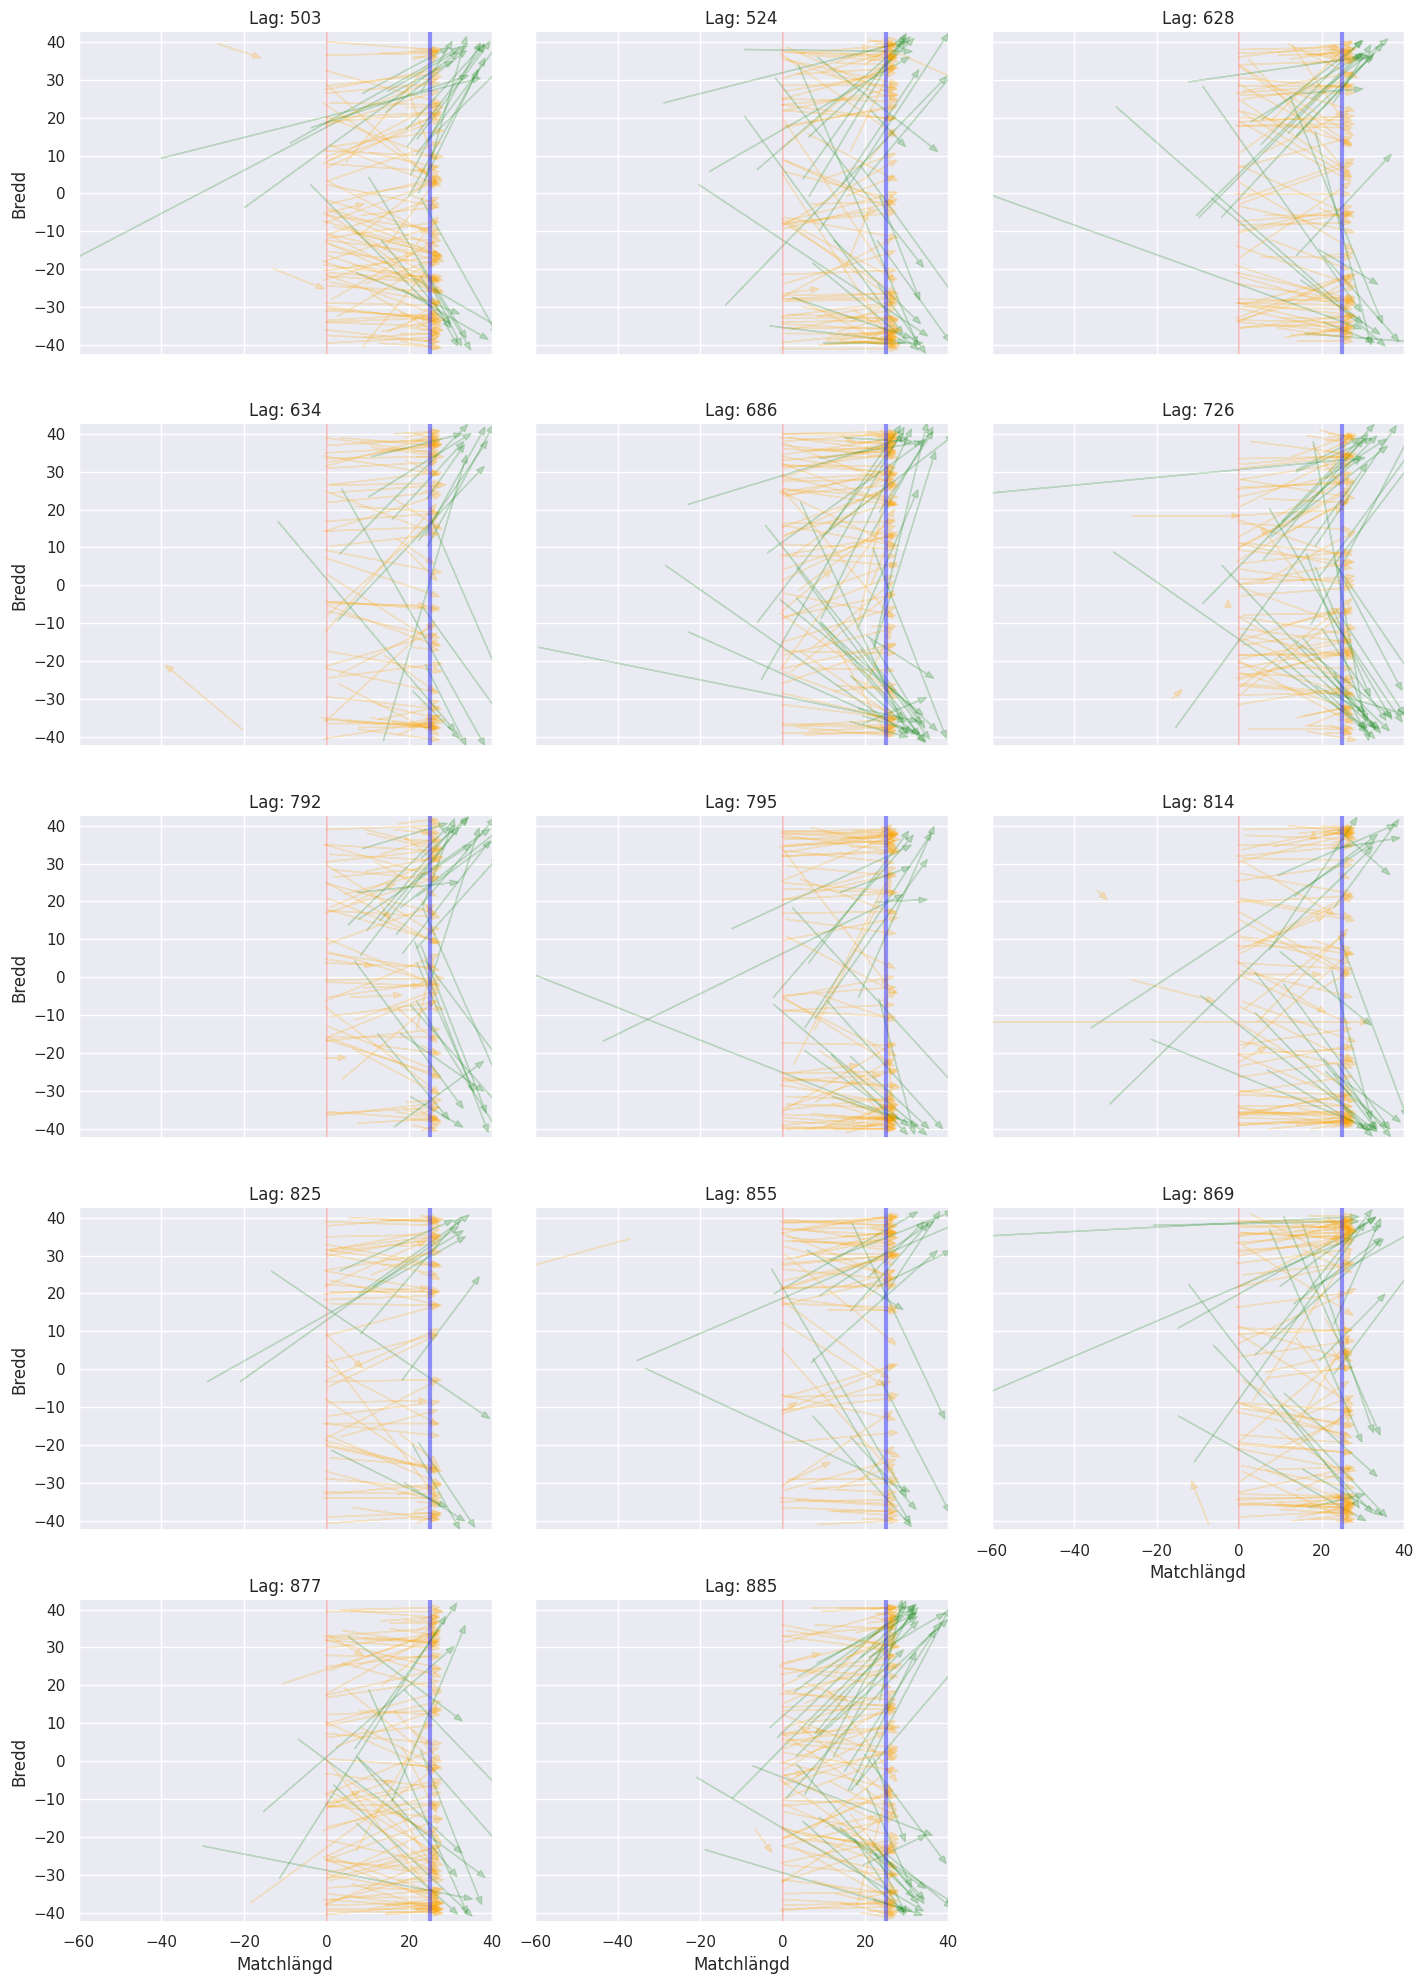

In [23]:
# 1. Hitta händelsen precis innan varje kontrollerat intåg i PP
pp_entries = df[
    (df['eventname'] == 'controlledentry') & 
    (df['manpowersituation'] == 'powerPlay')
].copy()

entry_data = []

for _, entry in pp_entries.iterrows():
    prior = df[
        (df['gameid'] == entry['gameid']) & 
        (df['teamid'] == entry['teamid']) & 
        (df['compiledgametime'] < entry['compiledgametime'])
    ].sort_values('compiledgametime', ascending=False).head(1)
    
    if not prior.empty:
        entry_data.append({
            'teamid': entry['teamid'],
            'start_x': prior.iloc[0]['xadjcoord'],
            'start_y': prior.iloc[0]['yadjcoord'],
            'end_x': entry['xadjcoord'],
            'end_y': entry['yadjcoord'],
            'event': prior.iloc[0]['eventname']
        })

plot_df = pd.DataFrame(entry_data)

# 2. Skapa FacetGrid - en rinka per lag
# Vi väljer de lag som har tillräckligt med data för att visa mönster
top_teams = plot_df['teamid'].value_counts().index
facet_df = plot_df[plot_df['teamid'].isin(top_teams)]

g = sns.FacetGrid(facet_df, col="teamid", col_wrap=3, height=4, aspect=1.2)

# 3. Funktion för att rita pilar och rinklinjer på varje delplot
def draw_entry_system(data, **kwargs):
    ax = plt.gca()
    # Rita linjer
    ax.axvline(0, color='red', alpha=0.2)
    ax.axvline(25, color='blue', alpha=0.4, lw=3)
    
    # Rita pilar för detta lag
    for _, row in data.iterrows():
        color = 'green' if row['event'] == 'pass' else 'orange'
        ax.arrow(row['start_x'], row['start_y'], 
                 row['end_x'] - row['start_x'], row['end_y'] - row['start_y'], 
                 head_width=1.5, head_length=2, fc=color, ec=color, alpha=0.2)
    
    ax.set_xlim(-60, 40)
    ax.set_ylim(-42.5, 42.5)

g.map_dataframe(draw_entry_system)
g.set_titles("Lag: {col_name}")
g.set_axis_labels("Matchlängd", "Bredd")

plt.tight_layout()
plt.show()

In [24]:
# 1. Hitta alla kontrollerade intång i PP
pp_entries = df[
    (df['eventname'] == 'controlledentry') & 
    (df['manpowersituation'] == 'powerPlay')
].copy()

# 2. Skapa en funktion för att kategorisera korridoren baserat på Y-koordinaten
def get_corridor(y):
    if y > 14:
        return 'Vänster'
    elif y < -14:
        return 'Höger'
    else:
        return 'Mitten'

# Applicera kategoriseringen
pp_entries['korridor'] = pp_entries['yadjcoord'].apply(get_corridor)

# 3. Gruppera per lag och räkna antal
corridor_stats = pp_entries.groupby(['teamid', 'korridor']).size().unstack(fill_value=0)

# 4. Räkna ut procentuell fördelning för varje lag
corridor_pct = corridor_stats.div(corridor_stats.sum(axis=1), axis=0) * 100

# Snygga till tabellen: sortera efter de som går mest i mitten
corridor_pct = corridor_pct[['Vänster', 'Mitten', 'Höger']].sort_values(by='Mitten', ascending=False)

print("Andel av Powerplay-ingångar per korridor (%):")
print(corridor_pct.round(1))

Andel av Powerplay-ingångar per korridor (%):
korridor  Vänster  Mitten  Höger
teamid                          
792          44.7    22.3   33.0
503          31.9    22.2   45.9
877          30.9    21.1   48.0
885          42.0    21.0   37.1
628          40.2    18.8   41.1
869          40.8    17.6   41.6
814          36.1    17.6   46.3
726          38.8    17.4   43.8
686          51.2    16.3   32.6
825          48.7    14.5   36.8
524          42.1    13.5   44.4
855          58.4    13.5   28.1
634          51.1    13.3   35.6
795          40.4     9.2   50.5


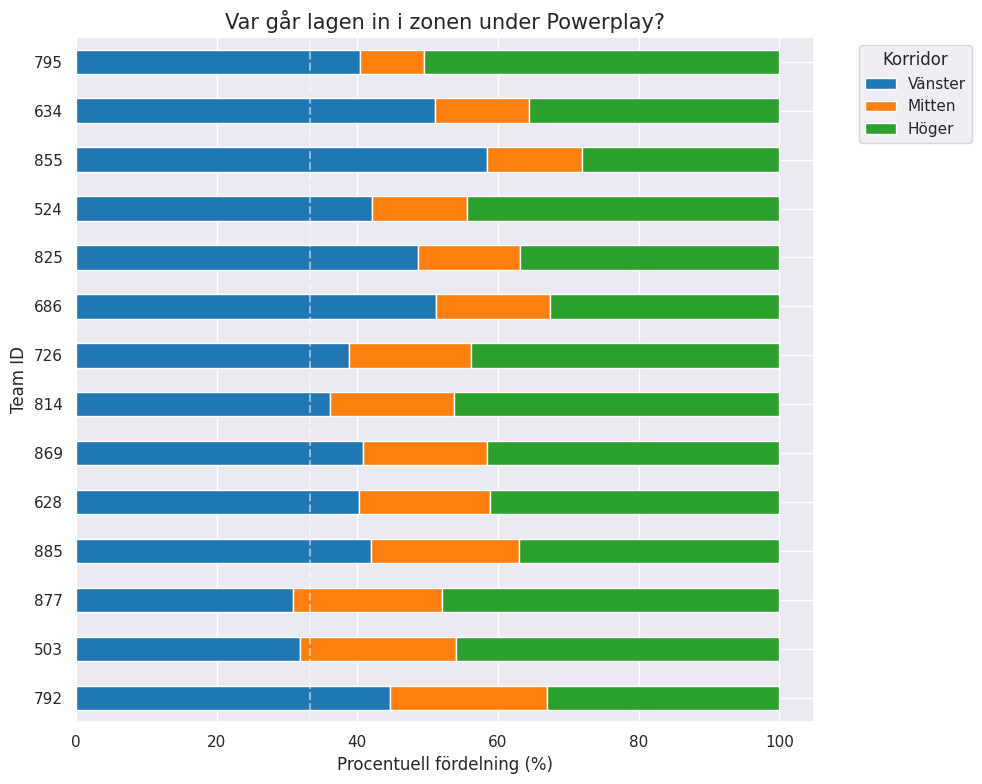

In [25]:
corridor_pct.plot(kind='barh', stacked=True, figsize=(10, 8), color=['#1f77b4', '#ff7f0e', '#2ca02c'])

plt.title('Var går lagen in i zonen under Powerplay?', fontsize=15)
plt.xlabel('Procentuell fördelning (%)')
plt.ylabel('Team ID')
plt.legend(title='Korridor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axvline(33.3, color='white', linestyle='--', alpha=0.5) # Referenslinje för jämn fördelning
plt.tight_layout()
plt.show()

### Identify bumper sequences

In [26]:
# 1. Definiera bumper-zonen (Slottet)
def is_in_bumper_slot(x, y):
    return (50 <= x <= 75) and (-15 <= y <= 15)

# 2. Hämta alla skott/mål i Powerplay
pp_attempts = df[
    (df['manpowersituation'] == 'powerPlay') & 
    ((df['eventname'] == 'shot') | (df['eventname'] == 'goal'))
].copy()

results = []

for _, attempt in pp_attempts.iterrows():
    # Hitta händelsen precis innan
    prior = df[
        (df['gameid'] == attempt['gameid']) & 
        (df['teamid'] == attempt['teamid']) & 
        (df['compiledgametime'] < attempt['compiledgametime'])
    ].sort_values('compiledgametime', ascending=False).head(1)
    
    used_bumper = False
    if not prior.empty and prior.iloc[0]['eventname'] == 'reception':
        # Om mottagningen av passen skedde i bumper-zonen
        if is_in_bumper_slot(prior.iloc[0]['xadjcoord'], prior.iloc[0]['yadjcoord']):
            used_bumper = True
            
    results.append({
        'used_bumper': used_bumper,
        'is_goal': 1 if attempt['eventname'] == 'goal' else 0,
        'xg': attempt['xg_allattempts']
    })

bumper_df = pd.DataFrame(results)

# Beräkna statistik
stats = bumper_df.groupby('used_bumper').agg({
    'xg': 'mean',
    'is_goal': 'mean'
}).reset_index()

stats['is_goal'] = stats['is_goal'] * 100 # Gör till procent
stats.columns = ['Använde Bumper', 'Genomsnittlig xG', 'Målprocent (%)']

print(stats)

   Använde Bumper  Genomsnittlig xG  Målprocent (%)
0           False          0.066464        8.000000
1            True          0.098706        0.373134


### Calculate average xG per shot

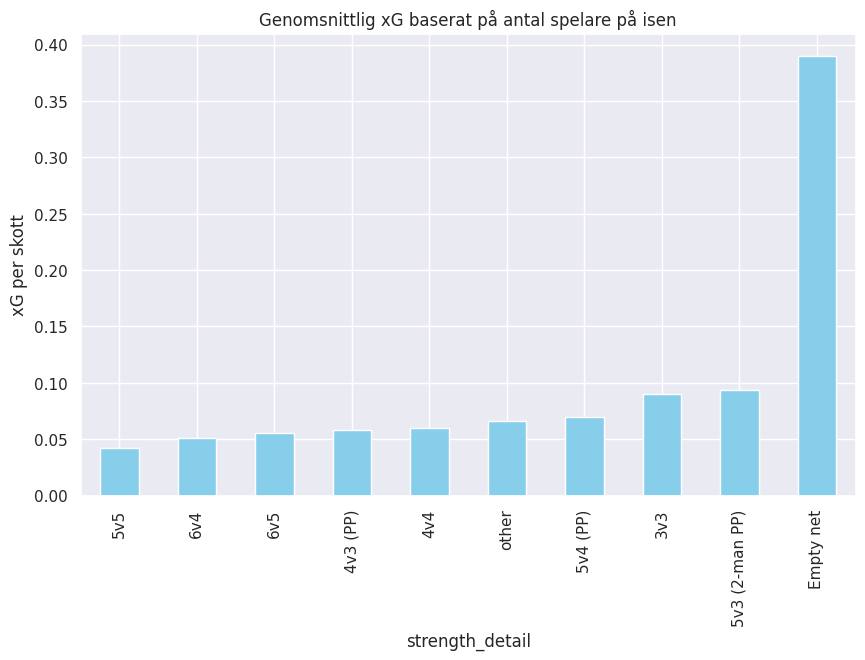

teamskatersonicecount  opposingteamskatersonicecount
4                      5                                250
3                      4                                  4
                       5                                  1
dtype: int64


In [27]:
# 1. Definiera funktionen (Som du skrev)
def identify_strength(row):
    # Vi utgår från att teamid är laget som utför händelsen
    # teamskatersonicecount är det egna lagets spelare
    home = row['teamskatersonicecount']
    away = row['opposingteamskatersonicecount']
    
    has_opposing_goalie = pd.notnull(row['opposingteamgoalieoniceid'])
    
    if not has_opposing_goalie:
        return 'Empty net'
    
    #Even strength categories
    if home == 5 and away == 5:
        return '5v5'
    elif (home == 4 and away == 4):
        return '4v4'
    elif (home == 3 and away == 3):
        return '3v3'
    
    #Powerplay categories
    elif (home == 5 and away == 4): # Vi fokuserar på när det egna laget har PP
        return '5v4 (PP)'
    elif (home == 5 and away == 3):
        return '5v3 (2-man PP)'
    elif (home == 4 and away == 3):
        return '4v3 (PP)'
    
    #Goalie is pulled from net
    elif (home == 6 and away == 5):
        return '6v5'
    elif (home == 6 and away == 4):
        return '6v4'
    elif (home == 6 and away == 3):
        return '6v3'
    return 'other'
    
    
    

# 2. Applicera på din dataframe
df['strength_detail'] = df.apply(identify_strength, axis=1)

# 3. Analysera xG
shot_analysis = df[df['eventname'].isin(['shot', 'goal'])].copy()
xg_stats = shot_analysis.groupby('strength_detail')['xg_allattempts'].mean().sort_values()

# 4. Visualisera skillnaden
plt.figure(figsize=(10, 6))
xg_stats.plot(kind='bar', color='skyblue')
plt.title('Genomsnittlig xG baserat på antal spelare på isen')
plt.ylabel('xG per skott')
plt.show()

other_breakdown = shot_analysis[shot_analysis['strength_detail'] == 'other'].groupby(
    ['teamskatersonicecount', 'opposingteamskatersonicecount']
).size().sort_values(ascending=False)

print(other_breakdown)

### xG per team

In [28]:
# Summera total xG per lag och situation
team_xg = shot_attempts.groupby(['teamid', 'manpowersituation'])['xg_allattempts'].sum().unstack()

# Beräkna effektivitets-ratio (hur mycket högre xG genererar laget i PP per skott?)
team_efficiency = shot_attempts.groupby(['teamid', 'manpowersituation'])['xg_allattempts'].mean().unstack()

print("\nGenomsnittlig xG per skott (per lag):")
print(team_efficiency)



NameError: name 'shot_attempts' is not defined